In [45]:
from numpy import *
from numpy.fft import fft, ifft, fftfreq, fftshift
from matplotlib.pyplot import *

In [46]:
T = 0.15
t = arange(-10, 10, T)
rect = (abs(t) <= 0.5).astype(int)
rect

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1,
       1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0])

In [47]:
rect.sum()  # even number of ones

6

In [50]:
Frect = T*fft(rect)
max(abs(imag(Frect))) # not real, even though rect is real and even (symmetric). Why?
# Because there are an even number of ones (see above)

4.7638143839935274e-17

In [51]:
# How to fix it. 
T = 0.13
t = arange(-10, 10, T)
rect = (abs(t) <= 0.5).astype(int)
rect.sum()  # odd number. Yeee!!

7

In [52]:
Frect = T*fft(rect)
max(abs(imag(Frect))) # all real. Yeeee!

4.7638143839935274e-17

In [53]:
f = fftfreq(len(Frect), T)
f

array([ 0.        ,  0.04995005,  0.0999001 ,  0.14985015,  0.1998002 ,
        0.24975025,  0.2997003 ,  0.34965035,  0.3996004 ,  0.44955045,
        0.4995005 ,  0.54945055,  0.5994006 ,  0.64935065,  0.6993007 ,
        0.74925075,  0.7992008 ,  0.84915085,  0.8991009 ,  0.94905095,
        0.999001  ,  1.04895105,  1.0989011 ,  1.14885115,  1.1988012 ,
        1.24875125,  1.2987013 ,  1.34865135,  1.3986014 ,  1.44855145,
        1.4985015 ,  1.54845155,  1.5984016 ,  1.64835165,  1.6983017 ,
        1.74825175,  1.7982018 ,  1.84815185,  1.8981019 ,  1.94805195,
        1.998002  ,  2.04795205,  2.0979021 ,  2.14785215,  2.1978022 ,
        2.24775225,  2.2977023 ,  2.34765235,  2.3976024 ,  2.44755245,
        2.4975025 ,  2.54745255,  2.5974026 ,  2.64735265,  2.6973027 ,
        2.74725275,  2.7972028 ,  2.84715285,  2.8971029 ,  2.94705295,
        2.997003  ,  3.04695305,  3.0969031 ,  3.14685315,  3.1968032 ,
        3.24675325,  3.2967033 ,  3.34665335,  3.3966034 ,  3.44

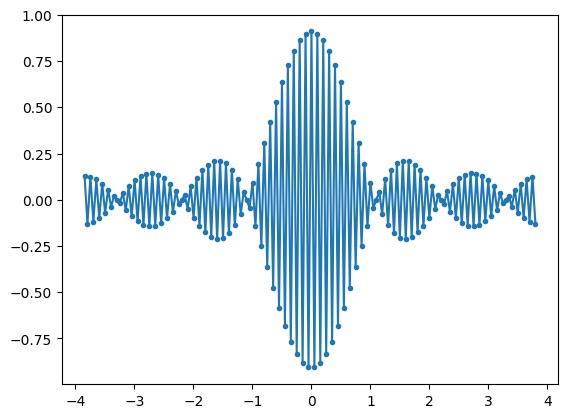

In [54]:
plot(fftshift(f), fftshift(real(Frect)), '.-')

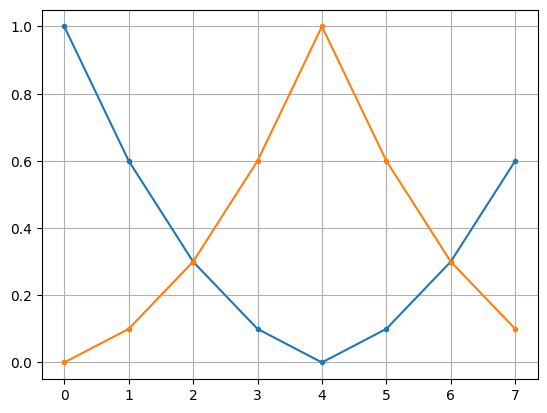

In [55]:
# Question: why do we have that high 'frequency' oscillation?
# Answer: because the rectangle should be centered around the 0 index of the array not in the middle
# Example:
# I want to calculate the Fourier transform of the peaked signal
# x = array([0, 0.1, 0.3, 0.6, 1.0, 0.6, 0.3, 0.1]
x = array([1, 0.6, 0.3, 0.1, 0, 0.1, 0.3, 0.6]) # the right way of representing a symmetric peak to be used in FFT
plot(x, '.-') # this is how it is stored -> not symmetric
plot(fftshift(x), '.-') # this is how it is interpreted by FFT  -> symmetric
grid()

**Time-shift property of the Fourier transform**
$$
\mathcal{F}\{x(t - t_0)\}(f) = X(f)\, e^{-2\pi i f t_0}
$$

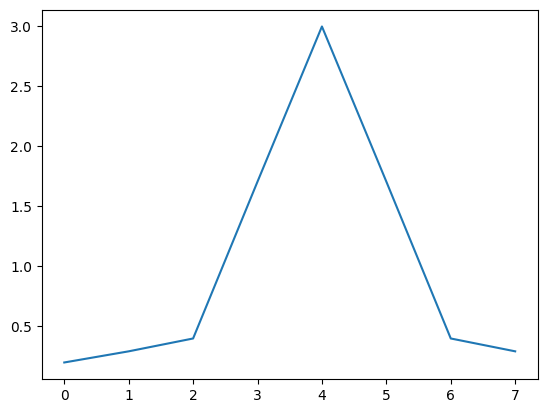

In [56]:
plot(fftshift(real(fft(x)))) # the correct way of representing the Fourier transform of the peaked function

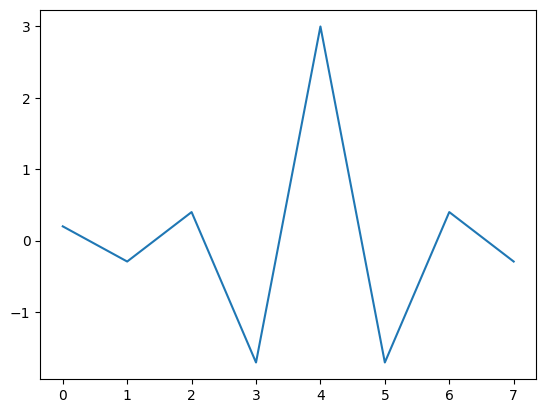

In [57]:
plot(fftshift(real(fft(fftshift(x))))) # we have an extra oscillation because of the fftshift(x). The outer fftshift is just for the better visualization of the FFT result.

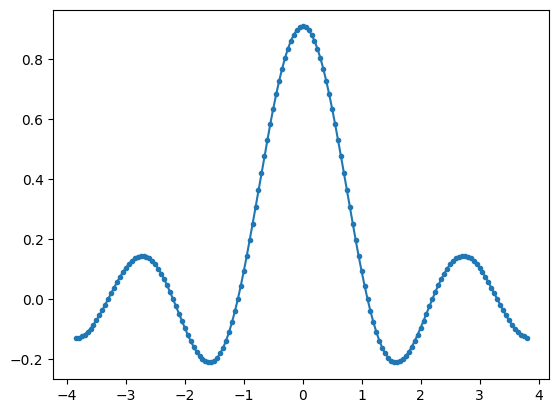

In [58]:
#getting back to the 'rect'-s FFT
#let's shift the function so that it is centered on the 0 index
Frect = T*fft(fftshift(rect))
plot(fftshift(f), fftshift(Frect),'.-') # Yeeee!

In [59]:
# Question: Why just three maxima?
# Answer: because of the 'thin' rectangle. Rule: small temporal scale -> large frequency scale
# Question: How to make it have more waves.
# Answer: increase temporal scale (without changing the size of the array)
T = 0.013 # higher resolution
t = arange(-1, 1, T) # smaller interval (with respect to the rectangle's width)
rect = (abs(t) <= 0.5).astype(int)
rect.sum()  # odd number. Yeee!!

77

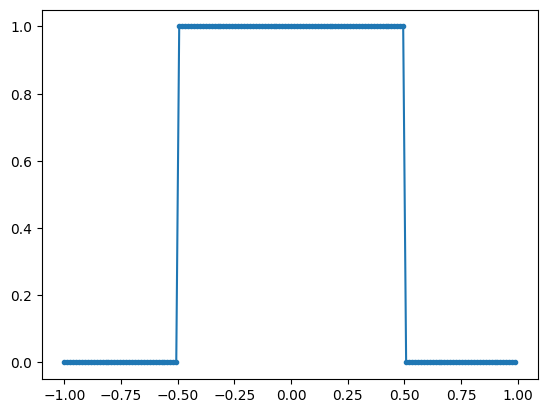

In [60]:
plot(t, rect, '.-')

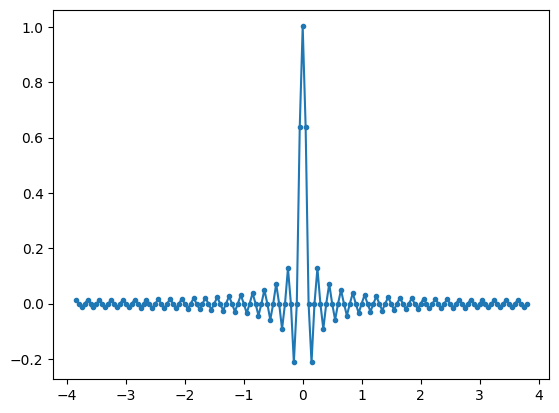

In [61]:
Frect = T*fft(fftshift(rect))
plot(fftshift(f), fftshift(Frect),'.-') # Yeee! large temporal scale -> small frequency scale

Let's check this:
$$
\mathcal{F}\left[e^{-t^2}\right]=\sqrt{\pi}e^{-\pi^2 f^2}
$$

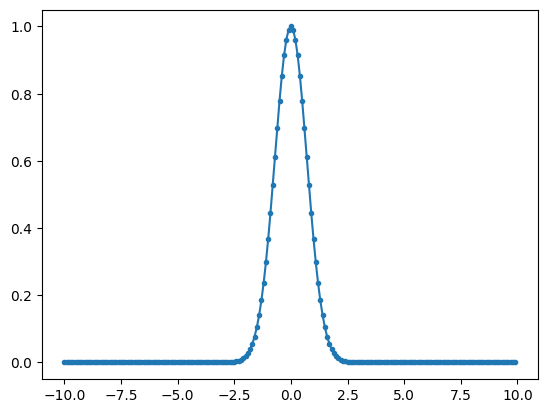

In [62]:
T = 0.1
t = arange(-10, 10, T)
x = exp(-t**2)
plot(t, x, '.-')

In [63]:
fftshift(x) # check whether the peak is indeed at index 0. Yeee!

array([1.00000000e+00, 9.90049834e-01, 9.60789439e-01, 9.13931185e-01,
       8.52143789e-01, 7.78800783e-01, 6.97676326e-01, 6.12626394e-01,
       5.27292424e-01, 4.44858066e-01, 3.67879441e-01, 2.98197279e-01,
       2.36927759e-01, 1.84519524e-01, 1.40858421e-01, 1.05399225e-01,
       7.73047404e-02, 5.55762126e-02, 3.91638951e-02, 2.70518469e-02,
       1.83156389e-02, 1.21551783e-02, 7.90705405e-03, 5.04176026e-03,
       3.15111160e-03, 1.93045414e-03, 1.15922917e-03, 6.82328053e-04,
       3.93669041e-04, 2.22629857e-04, 1.23409804e-04, 6.70548243e-05,
       3.57128496e-05, 1.86437423e-05, 9.54016287e-06, 4.78511739e-06,
       2.35257520e-06, 1.13372714e-06, 5.35534780e-07, 2.47959602e-07,
       1.12535175e-07, 5.00621802e-08, 2.18295780e-08, 9.33028757e-09,
       3.90893843e-09, 1.60522806e-09, 6.46143177e-10, 2.54938188e-10,
       9.85950558e-11, 3.73757133e-11, 1.38879439e-11, 5.05825274e-12,
       1.80583144e-12, 6.31928589e-13, 2.16756888e-13, 7.28772410e-14,
      

In [64]:
X = T*fft(fftshift(x))
f = fftfreq(len(x), T)
# check if its real
max(abs(imag(X))) # Yeee!

5.338483201215879e-14

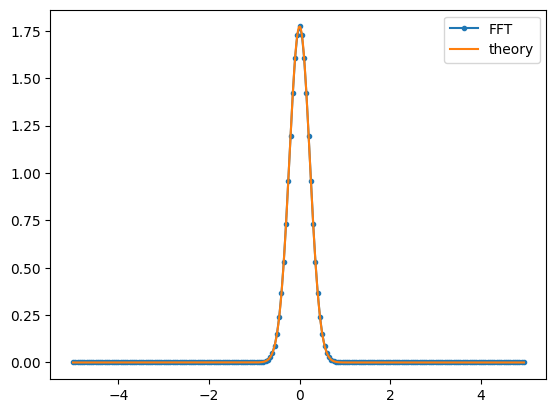

In [65]:
plot(fftshift(f), fftshift(X), '.-', label='FFT')
# compare with theory
ff = linspace(f.min(), f.max(), 10000)
plot(ff, sqrt(pi)*exp(-pi*pi*ff**2), label='theory')
legend() # Yeeee!